In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle

# Importando espectros

In [3]:
data = pd.read_csv('espectros_v3_clean.csv')

data.head()

,tag,artigo,grupo,500,502,504,506,508,510,512,...,722,724,726,728,730,732,734,736,738,740
0,1B,1,1,20.24,19.24,18.58,18.32,17.45,16.99,16.53,...,8.30,7.90,7.63,7.30,6.97,6.70,6.37,6.17,5.77,5.51
1,3,3,2,19.80,19.28,18.74,18.42,17.54,16.97,16.28,...,2.97,2.89,2.83,2.81,2.63,2.54,2.51,2.44,2.34,2.31
2,4A,4,2,10.58,10.10,9.65,9.39,9.06,8.97,8.79,...,1.87,1.83,1.74,1.72,1.63,1.61,1.58,1.54,1.50,1.48
3,4B,4,2,9.27,9.06,8.89,8.68,8.61,8.54,8.47,...,1.79,1.72,1.70,1.66,1.58,1.54,1.51,1.50,1.44,1.38
4,4C,4,2,9.46,8.72,8.69,8.50,8.31,8.16,8.08,...,2.37,2.26,2.25,2.20,2.10,2.03,2.02,1.90,1.80,1.78


In [4]:
aux = list(range(500,741,2))

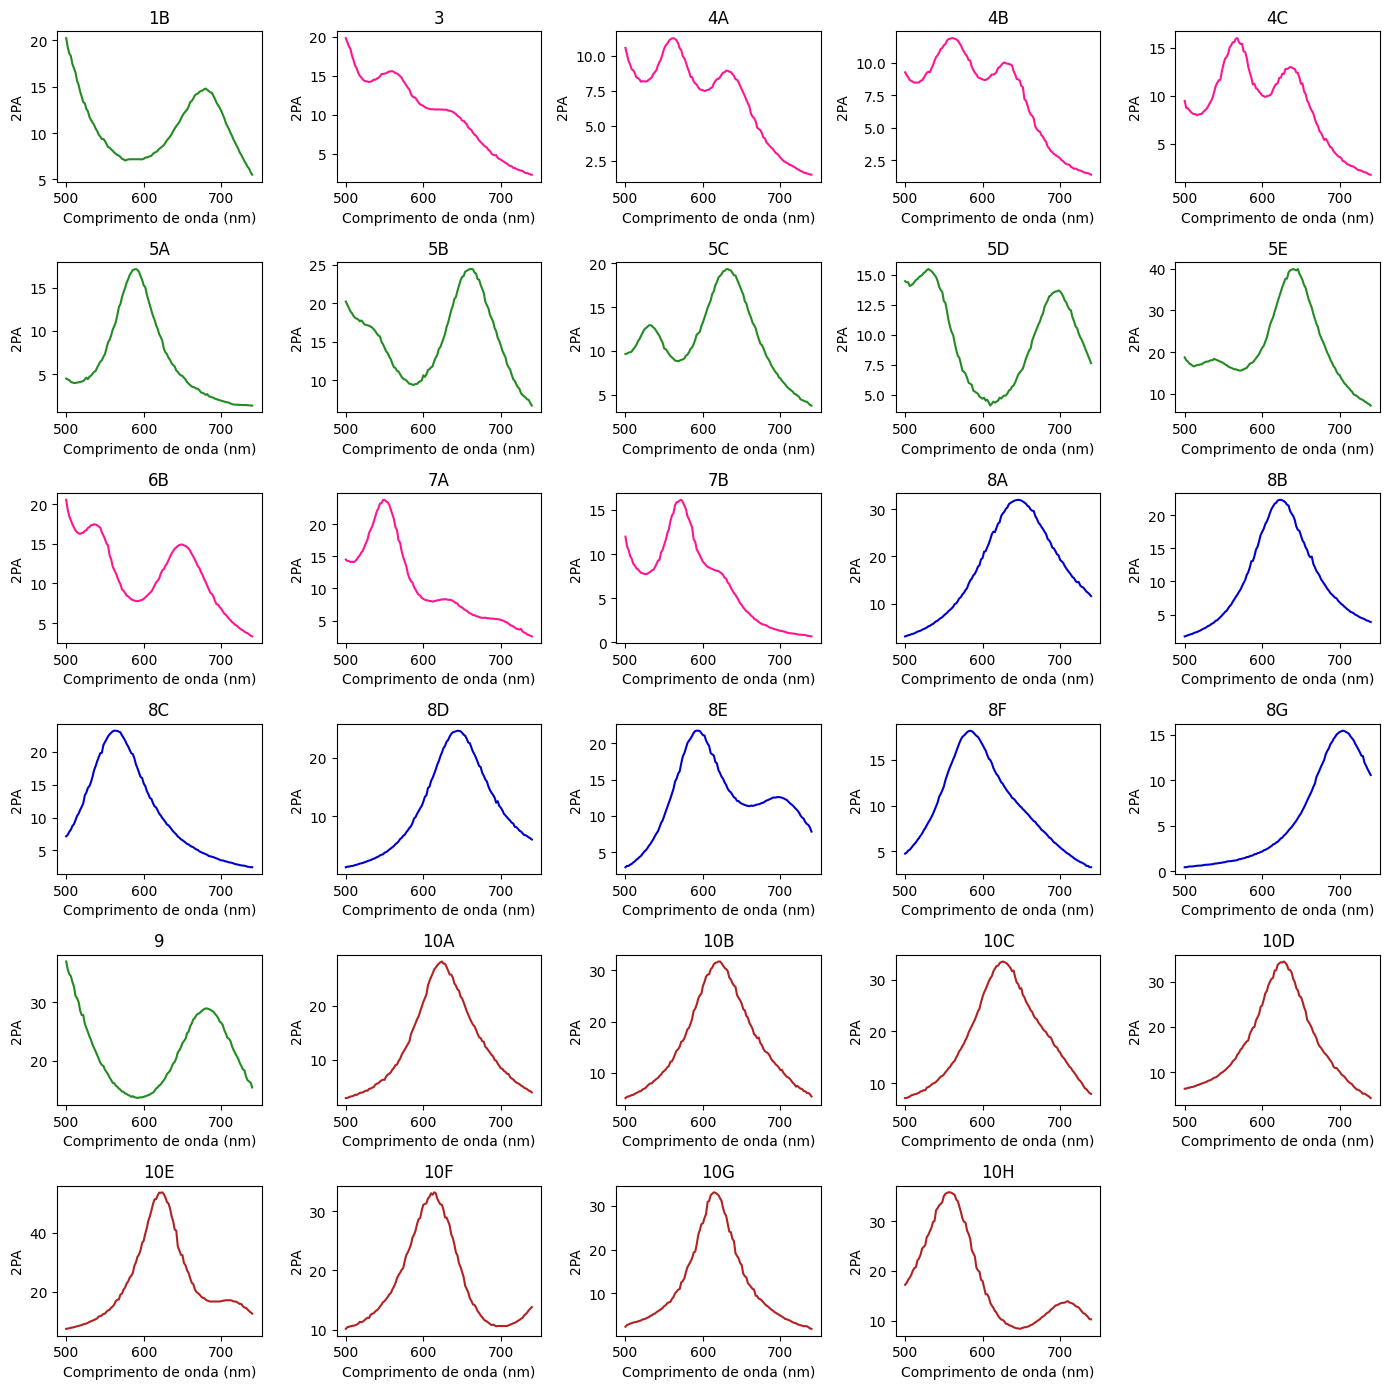

In [6]:
cols = 5
rows = int(np.ceil(len(data)/cols))

fig, axes = plt.subplots(rows, cols, figsize= (14,14))
axes = axes.flatten()
colors = {'1':'forestgreen', '2':'deeppink', '3':'mediumblue', '4':'firebrick'}

for i, (mol, grupo) in enumerate(zip(data['tag'], data['grupo'])):
    ax = axes[i]
    x_data = aux
    y_data = data.iloc[:, 3: ].iloc[i, :]
    ax.plot(x_data, y_data, color = colors[str(grupo)] )
    ax.set_xlabel('Comprimento de onda (nm)')
    ax.set_ylabel('2PA')
    ax.set_title(mol)

for ax in axes[i+1:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# PCA

In [7]:
X = data.iloc[:, 3: ]
y = data.iloc[:, :1]

In [8]:
scale = StandardScaler()

X_scaled = scale.fit_transform(X)


In [9]:
X_scaled = pd.DataFrame(X_scaled)
X_scaled.set_axis(aux, axis = 1)
X_scaled.head(3)

,0,1,2,3,4,5,6,7,8,9,...,111,112,113,114,115,116,117,118,119,120
0,1.226872,1.178539,1.133938,1.130692,1.052039,1.015782,0.988583,0.868271,0.792892,0.699070,...,0.182663,0.142739,0.131102,0.105840,0.070947,0.053033,0.019540,0.009042,-0.042099,-0.059535
1,1.172173,1.183736,1.155321,1.144304,1.064668,1.012915,0.951402,0.910474,0.817191,0.780381,...,-0.901602,-0.897830,-0.890702,-0.878547,-0.887141,-0.899027,-0.888068,-0.880106,-0.871328,-0.854479
2,0.025978,-0.009051,-0.059494,-0.084864,-0.125221,-0.133968,-0.162516,-0.215431,-0.236752,-0.261026,...,-1.125371,-1.117990,-1.122737,-1.117519,-1.107899,-1.111868,-1.106740,-1.094646,-1.074405,-1.060668


In [10]:
X_scaled.describe().round(3)

,0,1,2,3,4,5,6,7,8,9,...,111,112,113,114,115,116,117,118,119,120
count,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000,...,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000,29.000
mean,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,...,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018,...,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018,1.018
min,-1.232,-1.262,-1.281,-1.290,-1.321,-1.341,-1.385,-1.402,-1.421,-1.465,...,-1.321,-1.315,-1.308,-1.306,-1.282,-1.290,-1.297,-1.288,-1.265,-1.259
25%,-0.734,-0.755,-0.774,-0.808,-0.832,-0.852,-0.879,-0.886,-0.893,-0.890,...,-0.902,-0.898,-0.891,-0.879,-0.874,-0.881,-0.881,-0.866,-0.840,-0.817
50%,-0.137,-0.188,-0.188,-0.206,-0.188,-0.196,-0.210,-0.226,-0.249,-0.261,...,-0.253,-0.231,-0.246,-0.269,-0.320,-0.272,-0.293,-0.315,-0.332,-0.368
75%,0.512,0.543,0.570,0.558,0.590,0.617,0.667,0.699,0.741,0.749,...,0.679,0.670,0.640,0.645,0.625,0.582,0.593,0.548,0.512,0.517
max,3.310,3.311,3.308,3.332,3.306,3.268,3.155,3.140,3.051,2.905,...,2.628,2.575,2.573,2.566,2.590,2.479,2.441,2.462,2.492,2.402


In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [12]:
var = pca.explained_variance_ratio_*100

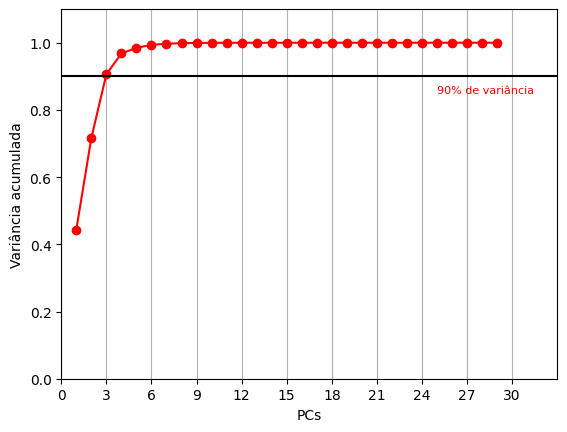

In [13]:
#grafico de variância acumulada x número de componentes
fig, ax = plt.subplots()

plt.xlabel('PCs')
plt.ylabel("Variância acumulada")


plt.plot(range(1,len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_),marker='o', c = 'r', label='Variância acumulada')

plt.ylim(0,1.1)
plt.xlim(0,33)

plt.xticks(np.arange(0,33, step=3))

plt.axhline(y=0.90, color='black', linestyle='-')
plt.text(25, 0.85, '90% de variância', color = 'red', fontsize=8)

ax.grid(axis='x')
plt.show()


In [15]:
df_artigos = pd.DataFrame(data= X_pca[:, 0:3], columns=['PC1', 'PC2', 'PC3'])
df_artigos = pd.concat([df_artigos, data[['grupo']]], axis=1)
df_artigos.head()

,PC1,PC2,PC3,grupo
0,-1.974808,1.873901,-7.073921,1
1,-6.135466,4.337281,0.920368,2
2,-9.505109,-0.494119,-0.935356,2
3,-9.043935,-0.179850,0.021145,2
4,-6.894456,0.331571,1.584036,2


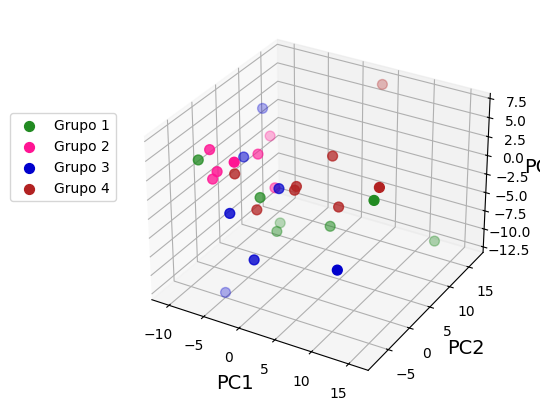

In [16]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

#for i, txt in enumerate(data['tag']):
#    ax.text(X_pca[i,0], X_pca[i,1], X_pca[i,2], txt, fontsize=8)


targets = list(range(1,5))
colors = ['forestgreen', 'deeppink', 'mediumblue', 'firebrick']
fig.patch.set_facecolor('white')
handles = []
for target, color in zip(targets,colors):
    indicesToKeep = df_artigos['grupo'] == target
    scatter = ax.scatter(df_artigos.loc[indicesToKeep, 'PC1'], df_artigos.loc[indicesToKeep, 'PC2'],
               df_artigos.loc[indicesToKeep, 'PC3'],
               c = color
               , s = 50)
    handles.append(scatter)

ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.set_zlabel("PC3", fontsize=14)
labels = [f'Grupo {i}' for i in targets]


ax.legend(labels, fontsize = 10, bbox_to_anchor = (0, 0.75))
ax.grid()
plt.savefig("plot3d_especsporartg.png", dpi=400)
plt.show()

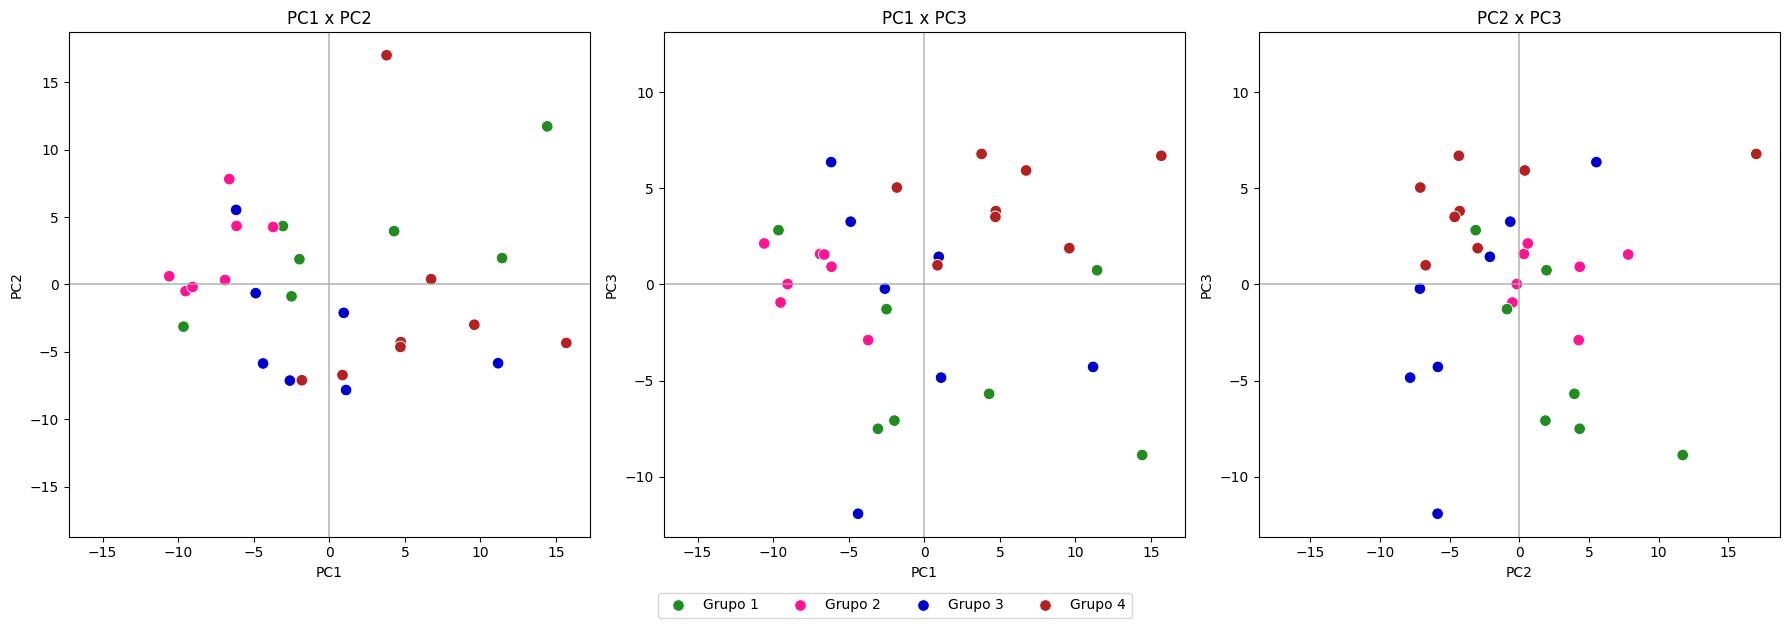

In [17]:

fig, axes = plt.subplots(1, 3, figsize= (18,6))
axes = axes.flatten()

pcs = [('PC1','PC2'), ('PC1','PC3'), ('PC2', 'PC3')]
titles = ['PC1 x PC2', 'PC1 x PC3', 'PC2 x PC3']

for ax, (x_pc, y_pc), title in zip(axes, pcs, titles):
    sns.scatterplot(data=df_artigos, x= x_pc, y= y_pc, hue='grupo',
                    palette=colors, ax=ax, s = 70)

    ax.set_title(title)
    ax.legend_.remove()

    x_lim = np.max(np.abs(df_artigos[x_pc])) * 1.1  # multiplicar por 1.1 para margem
    y_lim = np.max(np.abs(df_artigos[y_pc])) * 1.1
    ax.set_xlim(-x_lim, x_lim)
    ax.set_ylim(-y_lim, y_lim)

    ax.axhline(y=0, color='darkgray', linestyle='-', alpha=0.8, linewidth=1.2)
    ax.axvline(x=0, color='darkgray', linestyle='-', alpha=0.8, linewidth=1.2)


handles, labels = axes[0].get_legend_handles_labels()
labels = [f'Grupo {i}' for i in targets]
fig.legend(handles, labels, loc='lower center', ncol=4,
           frameon=True,fancybox=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# Reescontruindo os espectros

In [18]:
loadings = pca.components_.T*np.sqrt(pca.explained_variance_)
loadings = pd.DataFrame(loadings)
loadings.head(3)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.206602,0.806639,-0.303315,-0.345914,0.289022,0.168713,0.110505,-0.055390,0.016658,0.046414,...,-0.001565,0.001104,0.008055,0.006128,0.000598,0.005527,-0.001409,0.001115,0.000383,-6.592889e-17
1,0.223437,0.819118,-0.288134,-0.333489,0.287454,0.159263,0.092445,-0.043441,0.020252,0.038747,...,0.000069,-0.000117,-0.002273,0.001362,0.003149,0.001245,0.000148,0.002169,-0.001641,-1.157539e-16
2,0.232832,0.833578,-0.272220,-0.321651,0.277248,0.150053,0.082403,-0.042309,0.018169,0.026065,...,-0.000827,-0.001003,-0.004963,-0.000319,-0.000859,-0.002119,-0.000618,-0.001451,-0.001737,4.195949e-16


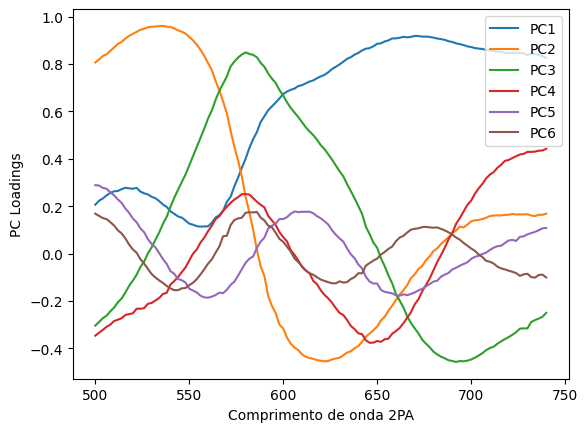

In [19]:
#grafico pc loadings vs comprimento de onda
for i in range(6):
    plt.plot(aux, loadings[i], label =f'PC{i+1}')
plt.legend()
plt.xlabel('Comprimento de onda 2PA')
plt.ylabel('PC Loadings')
plt.show()


In [20]:
X_scaled.head(3)

,0,1,2,3,4,5,6,7,8,9,...,111,112,113,114,115,116,117,118,119,120
0,1.226872,1.178539,1.133938,1.130692,1.052039,1.015782,0.988583,0.868271,0.792892,0.699070,...,0.182663,0.142739,0.131102,0.105840,0.070947,0.053033,0.019540,0.009042,-0.042099,-0.059535
1,1.172173,1.183736,1.155321,1.144304,1.064668,1.012915,0.951402,0.910474,0.817191,0.780381,...,-0.901602,-0.897830,-0.890702,-0.878547,-0.887141,-0.899027,-0.888068,-0.880106,-0.871328,-0.854479
2,0.025978,-0.009051,-0.059494,-0.084864,-0.125221,-0.133968,-0.162516,-0.215431,-0.236752,-0.261026,...,-1.125371,-1.117990,-1.122737,-1.117519,-1.107899,-1.111868,-1.106740,-1.094646,-1.074405,-1.060668


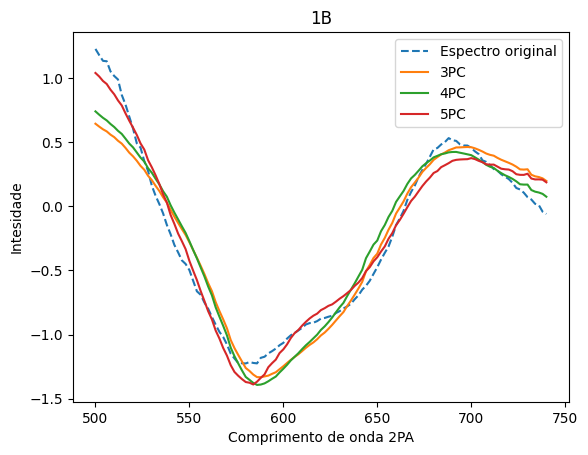

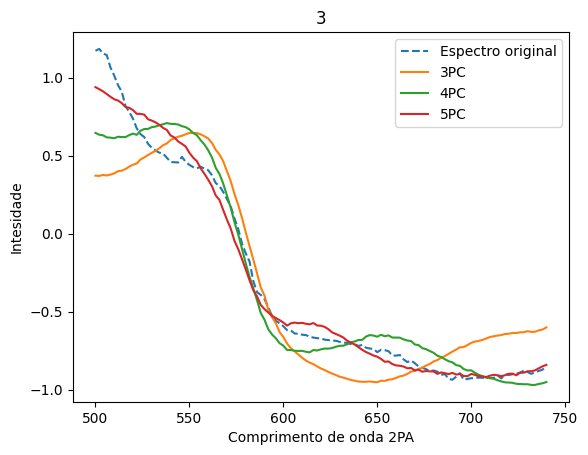

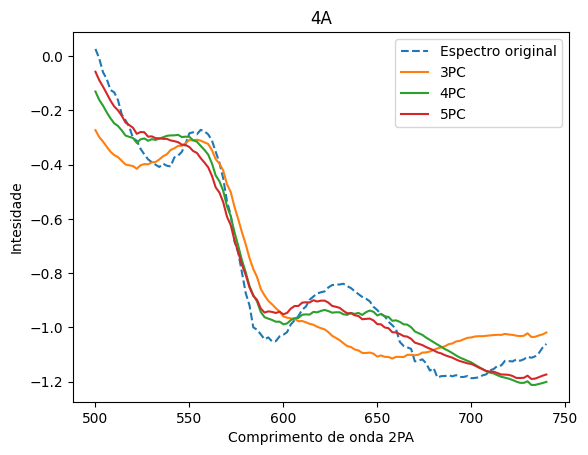

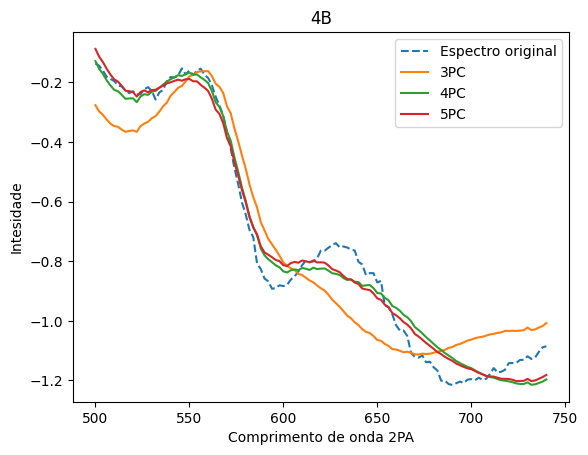

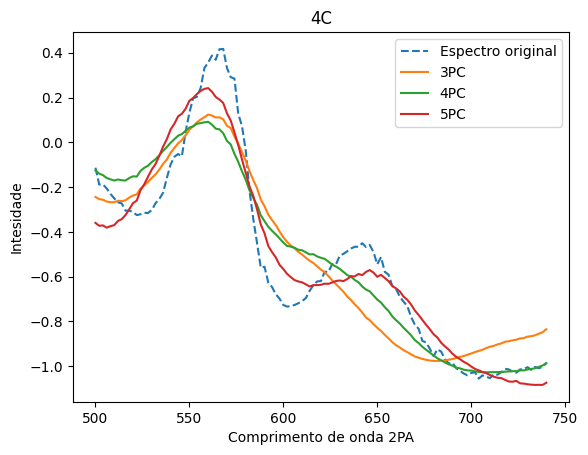

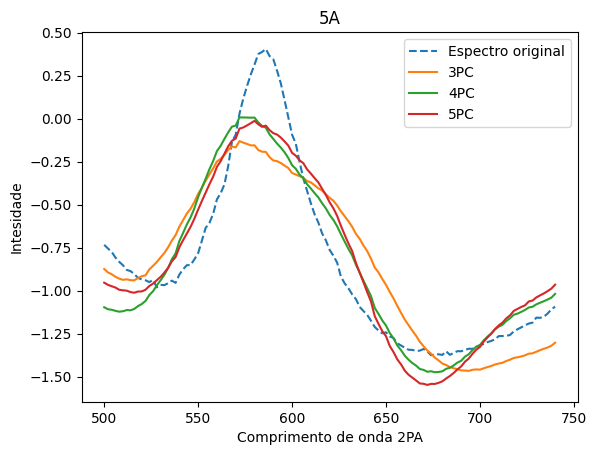

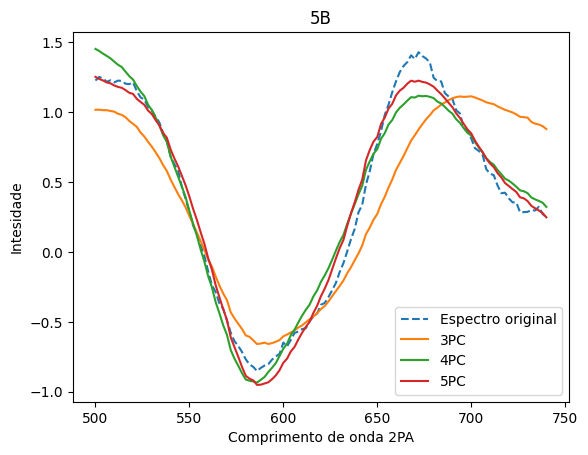

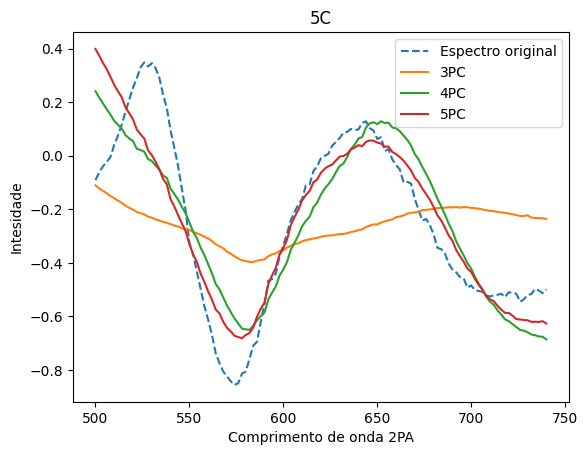

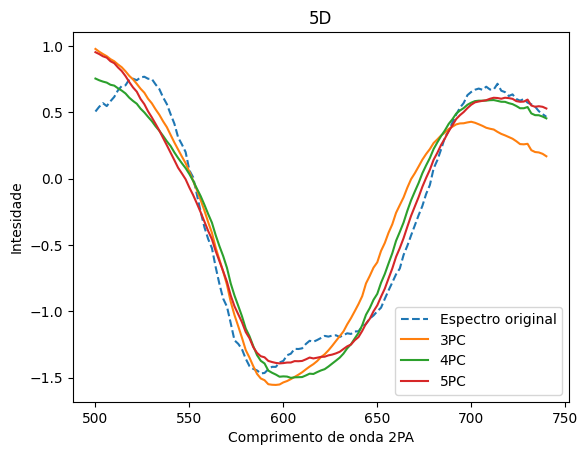

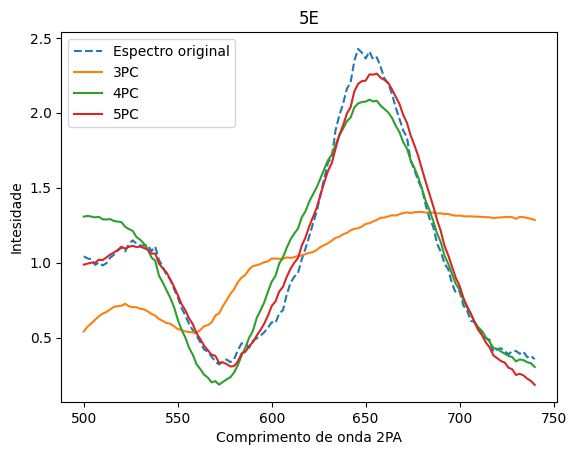

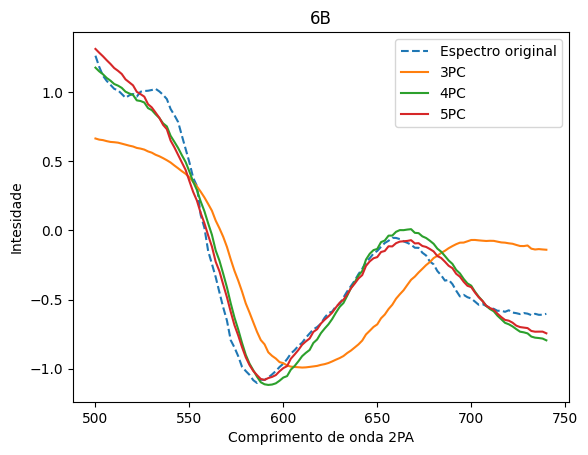

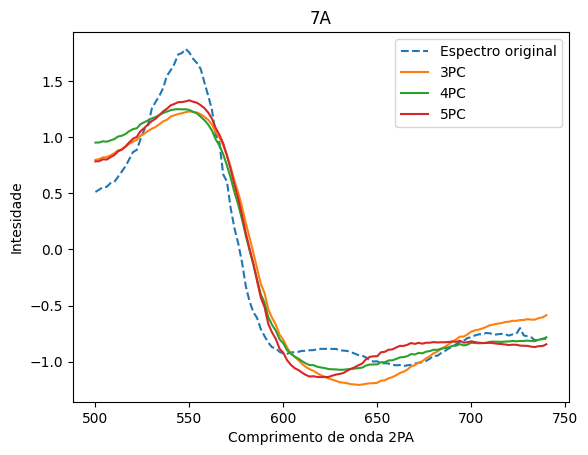

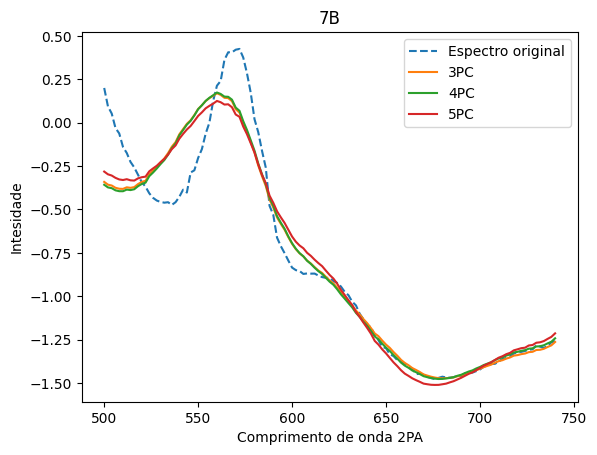

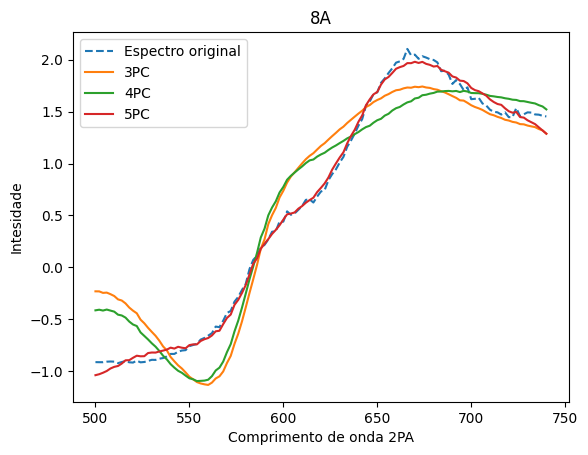

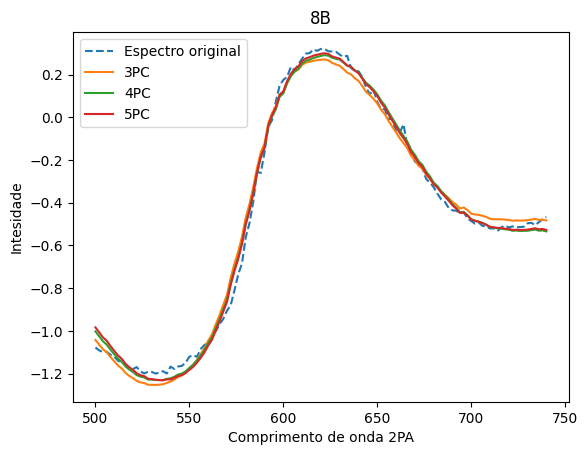

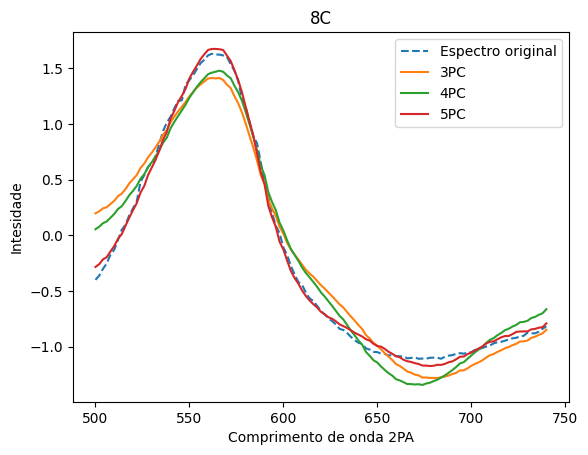

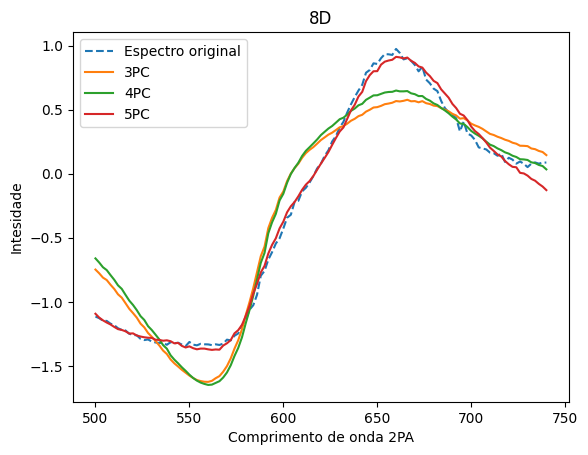

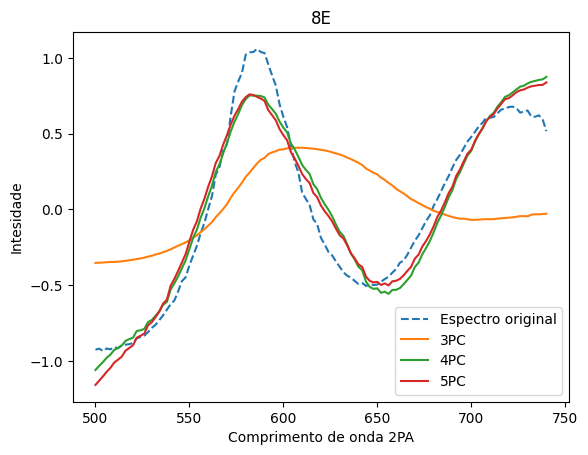

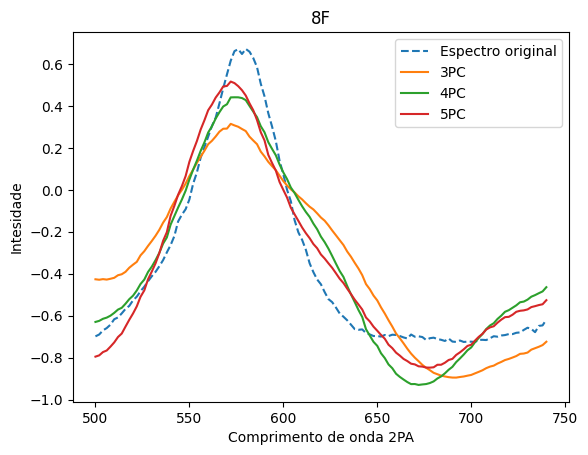

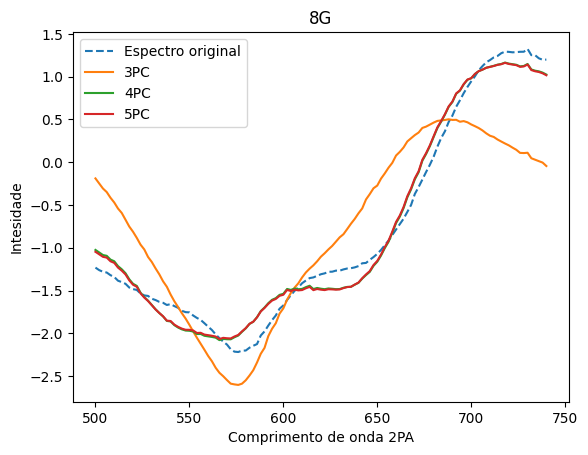

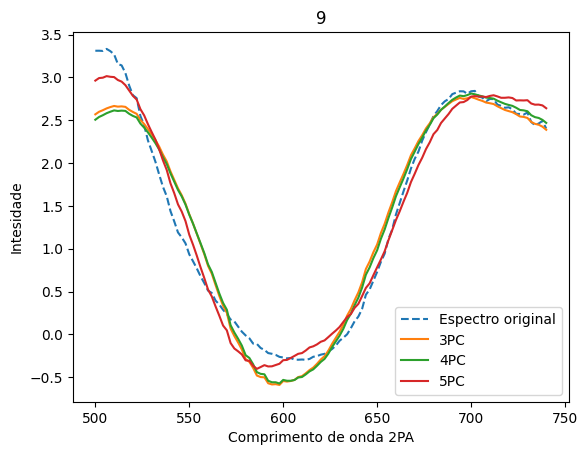

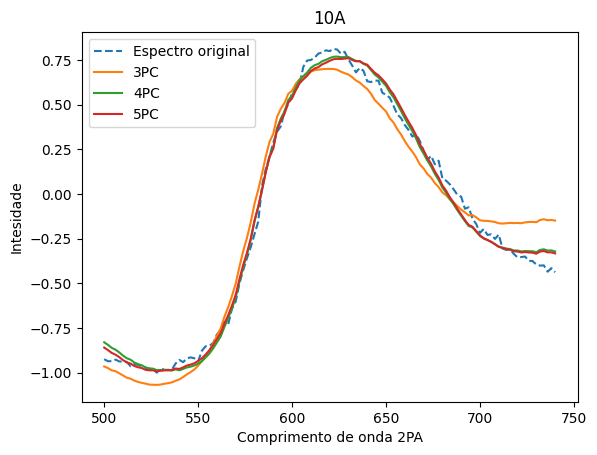

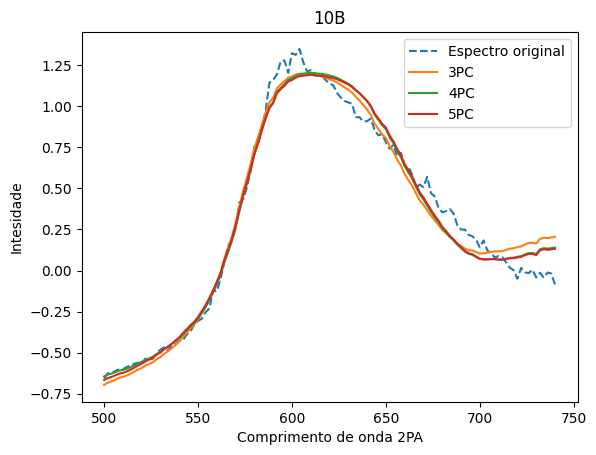

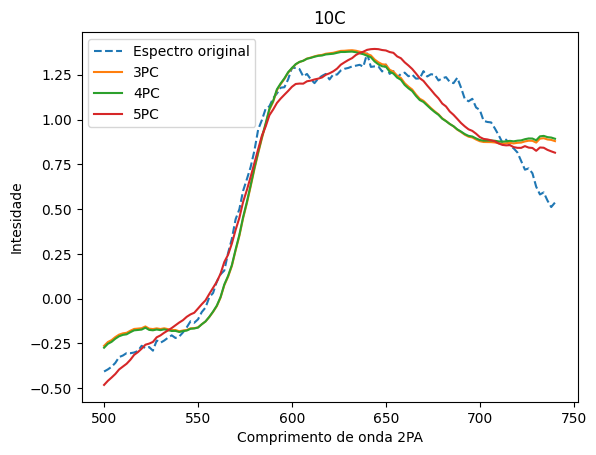

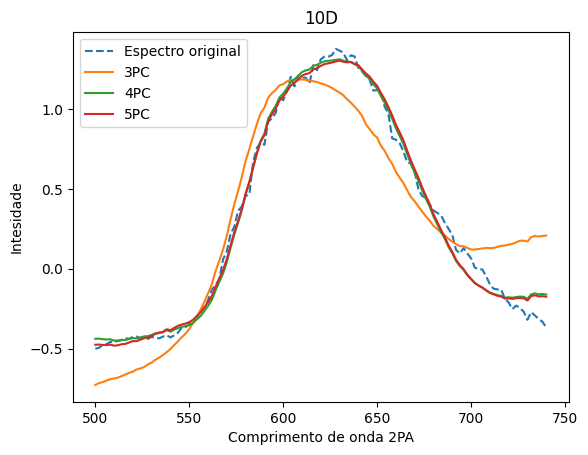

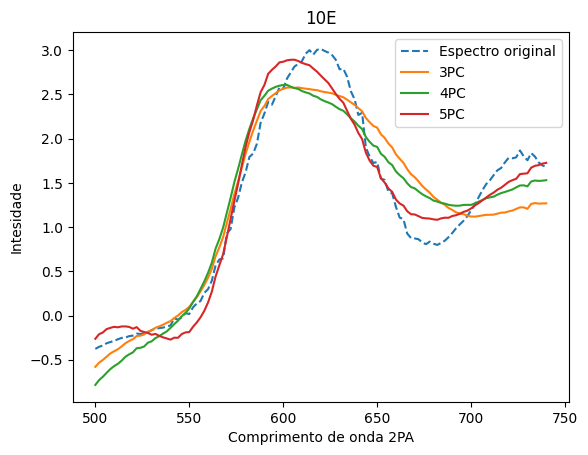

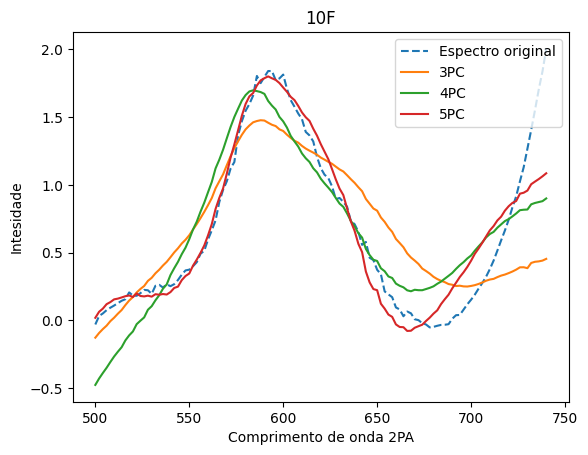

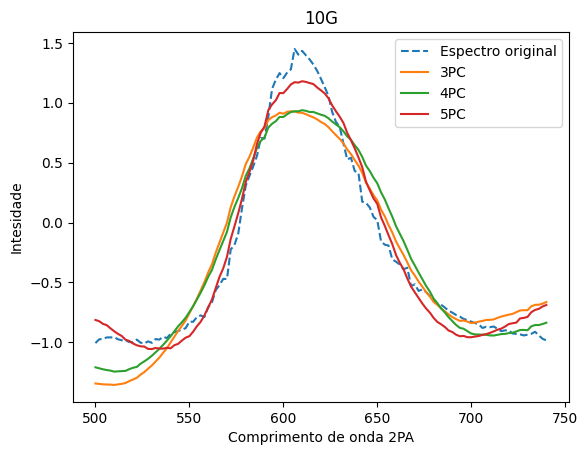

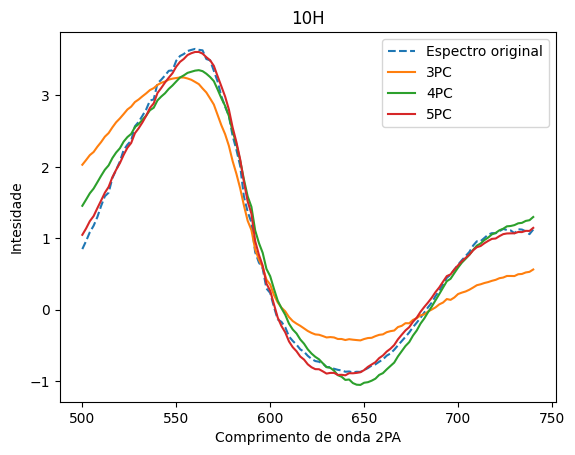

In [23]:
pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)
pca_4d = PCA(n_components=4)
X_pca4 = pca_4d.fit_transform(X_scaled)
pca_5d = PCA(n_components=5)
X_pca5 = pca_5d.fit_transform(X_scaled)
#mean = np.mean(X_scaled, axis=0)
scores = X_pca
components = pca.components_
mean = np.mean(X_scaled.values, axis=0)

# Reconstrução do espectro com todas PCs
reconstructed_data = np.dot(scores[:, :3], components[:3, :] ) + mean
reconstructed_data2 = np.dot(scores[:, :4], components[:4, :] ) + mean
reconstructed_data3 = np.dot(scores[:, :5], components[:5, :] ) + mean
#reconstructed_data2 = np.dot(scores[:, :pca_4d.n_components_], pca_4d.components_) + mean.values
#reconstructed_data3 = np.dot(scores[:, :pca_5d.n_components_], pca_5d.components_) + mean.values


for i in range(len(X)):
  x_data = aux
  y_data1 = X_scaled.iloc[i, :]
  y_data2 = reconstructed_data[i]
  y_data3 = reconstructed_data2[i]
  y_data4 = reconstructed_data3[i]
  plt.plot(x_data, y_data1, label='Espectro original', linestyle='--')
  plt.plot(x_data, y_data2, label='3PC', linestyle='-')
  plt.plot(x_data, y_data3, label='4PC', linestyle='-')
  plt.plot(x_data, y_data4, label='5PC', linestyle='-')


  plt.title(data['tag'][i])
  plt.xlabel('Comprimento de onda 2PA')
  plt.ylabel('Intesidade')
  plt.legend()
  plt.show()



In [27]:
from sklearn.metrics import mean_squared_error

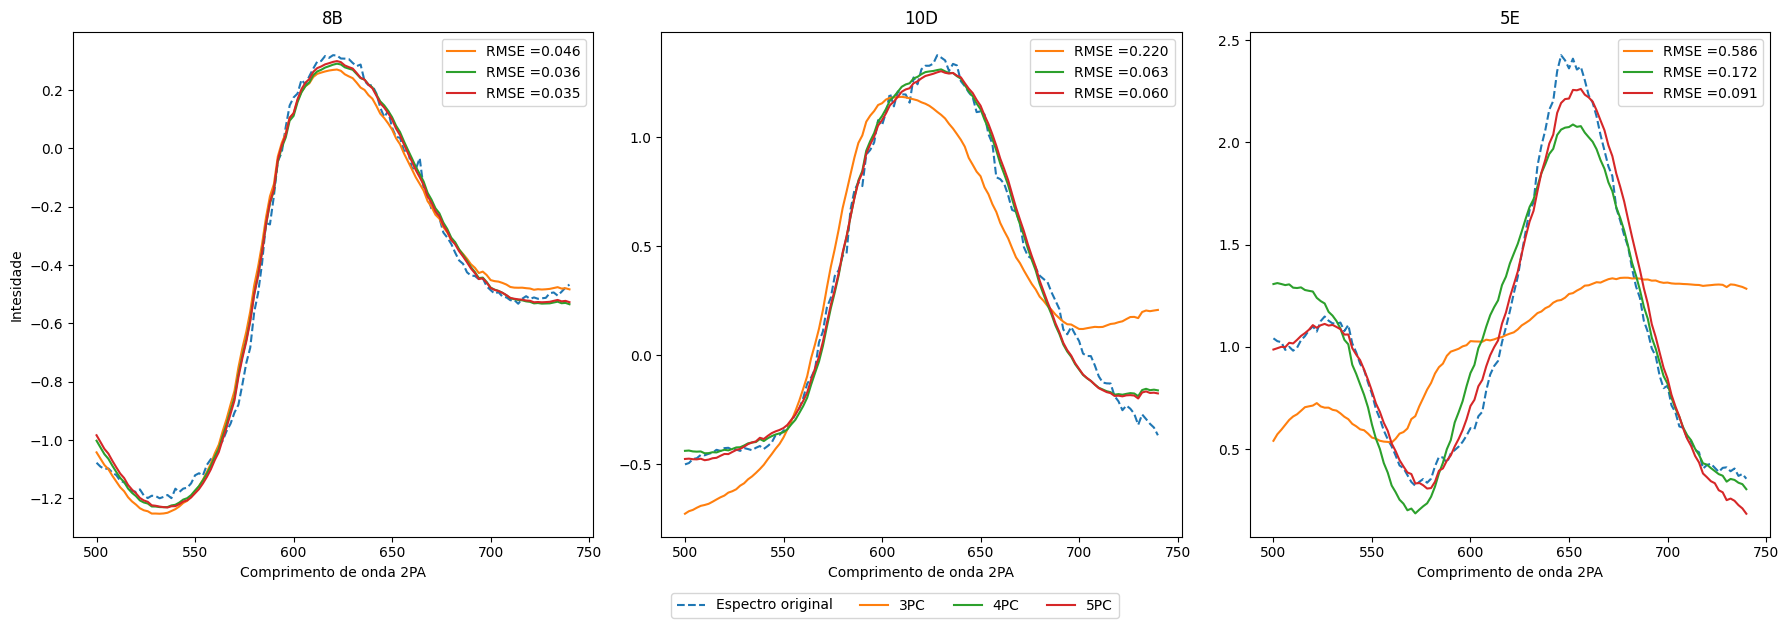

In [28]:
#moléculas 5E; 8B; 10D
tags = ['8B', '10D', '5E']
imgs = ['8B.png', '10D.png', '5E.png']

indices = [data[data['tag'] == tag].index[0] for tag in tags]

fig, axes = plt.subplots(1, len(indices), figsize= (18,6))
axes = axes.flatten()

for ax, i, tag, img in zip(axes, indices, tags, imgs):
  x_data = aux
  y_data1 = X_scaled.iloc[i, :]
  y_data2 = reconstructed_data[i]
  y_data3 = reconstructed_data2[i]
  y_data4 = reconstructed_data3[i]

  rmse_3 = np.sqrt(mean_squared_error(y_data1, y_data2))
  rmse_4 = np.sqrt(mean_squared_error(y_data1, y_data3))
  rmse_5 = np.sqrt(mean_squared_error(y_data1, y_data4))

  ax.plot(x_data, y_data1, linestyle='--')
  ax.plot(x_data, y_data2, linestyle='-', label = f'RMSE ={rmse_3:.3f}')
  ax.plot(x_data, y_data3, linestyle='-', label = f'RMSE ={rmse_4:.3f}')
  ax.plot(x_data, y_data4, linestyle='-', label = f'RMSE ={rmse_5:.3f}')

  ax.legend()
  ax.set_title(tag)
  ax.set_xlabel('Comprimento de onda 2PA')



labels = ['Espectro original', '3PC', '4PC', '5PC']
axes[0].set_ylabel('Intesidade')
fig.legend(labels, loc='lower center', ncol=4,bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

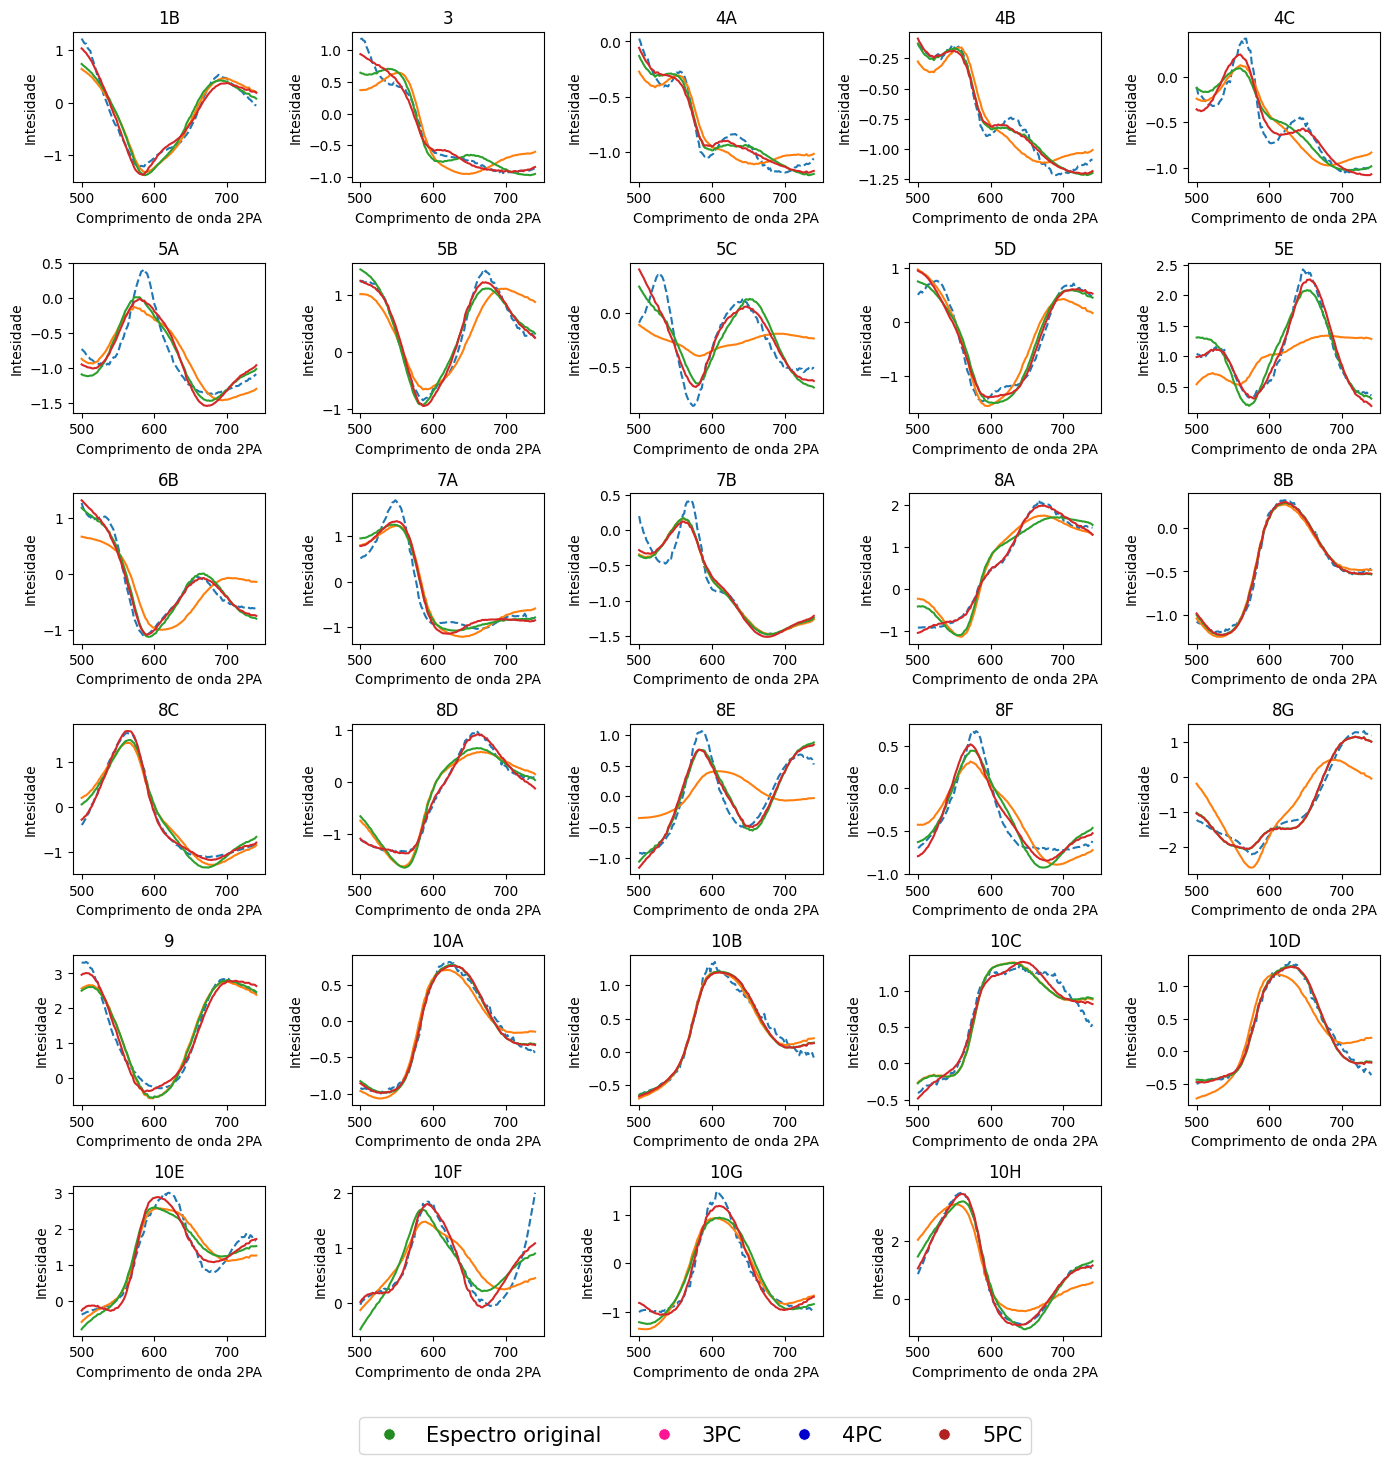

In [25]:
cols = 5
rows = int(np.ceil(len(data)/cols))

fig, axes = plt.subplots(rows, cols, figsize= (14,14))
axes = axes.flatten()

for i in range(len(X)):
  ax = axes[i]
  x_data = aux
  y_data1 = X_scaled.iloc[i, :]
  y_data2 = reconstructed_data[i]
  y_data3 = reconstructed_data2[i]
  y_data4 = reconstructed_data3[i]
  ax.plot(x_data, y_data1, label='Espectro original', linestyle='--')
  ax.plot(x_data, y_data2, label='3PC', linestyle='-')
  ax.plot(x_data, y_data3, label='4PC', linestyle='-')
  ax.plot(x_data, y_data4, label='5PC', linestyle='-')


  ax.set_title(data['tag'][i])
  ax.set_xlabel('Comprimento de onda 2PA')
  ax.set_ylabel('Intesidade')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

andles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()  # deixa espaço pro título/legenda
plt.show()